# Showcase — the GERD reservoir filling on the Blue Nile (2020 → 2024)

The Grand Ethiopian Renaissance Dam (GERD) impounds the Blue Nile; its reservoir was filled in stages between 2020 and 2024 — a process watched closely across the Nile basin. This notebook animates the reservoir growing **and** measures its **surface area** each year with the NDWI water index.

## What this notebook does

1. **Fetch** one dry-season Sentinel-2 composite per year (2020–2024).
2. **Animate** the reservoir filling (true colour).
3. **Measure** the water-surface area each year with NDWI and plot the growth.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY`; skips gracefully otherwise.

In [1]:
import os, tempfile, base64
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens"); logger.disable("pyramids")
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start,end]; return GeoTIFF path or None.
    aoi = [lon_min, lat_min, lon_max, lat_max]."""
    el = EarthLens(
        data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)},
        lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
    )
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001
        print("download skipped (needs GEE credentials):", exc); return None
    return str(p[0]) if p else None

def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")

import matplotlib.animation as manim
from IPython.display import HTML
AOI = [34.95, 11.05, 35.25, 11.32]   # GERD reservoir
C = "COPERNICUS/S2_SR_HARMONIZED"

# One Nov-Dec median composite per year. B4/B3/B2 = true colour, B8 = NIR (for NDWI).
frames, ndwis, labels = [], [], []
for y in range(2020, 2025):
    p = grab(C, AOI, f"{y}-11-01", f"{y}-12-28", ["B4", "B3", "B2", "B8"], scale=30)
    if not p:
        continue
    a = read(p)
    def st(b):
        lo, hi = np.nanpercentile(b, 2), np.nanpercentile(b, 98)
        return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)
    frames.append(np.dstack([st(a[i]) for i in range(3)]))
    ndwis.append((a[1] - a[3]) / (a[1] + a[3] + 1e-6))   # NDWI = (green - NIR)/(green + NIR)
    labels.append(str(y))
print(f"{len(frames)} yearly composites:", labels)

5 yearly composites: ['2020', '2021', '2022', '2023', '2024']


## Animated reservoir filling


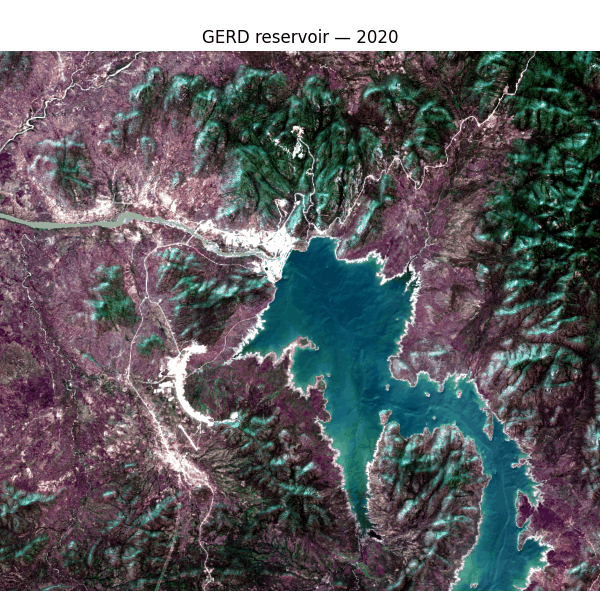

In [2]:
# Replay the yearly true-colour composites as a looping GIF.
if frames:
    fig, ax = plt.subplots(figsize=(6, 6)); fig.subplots_adjust(0, 0, 1, 0.93)
    def upd(i):
        ax.clear(); ax.imshow(frames[i]); ax.set_title(f"GERD reservoir — {labels[i]}"); ax.axis("off")
    anim = manim.FuncAnimation(fig, upd, frames=len(frames), interval=1000)
    gif = os.path.join(tempfile.mkdtemp(), "g.gif"); anim.save(gif, writer=manim.PillowWriter(fps=1.0)); plt.close(fig)
    display(HTML(f'<img src="data:image/gif;base64,{base64.b64encode(open(gif,"rb").read()).decode()}" style="max-width:520px"/>'))

## Reservoir surface area each year (NDWI)

NDWI > 0 marks open water; counting those pixels gives the reservoir's surface area, which climbs year on year as the dam fills.

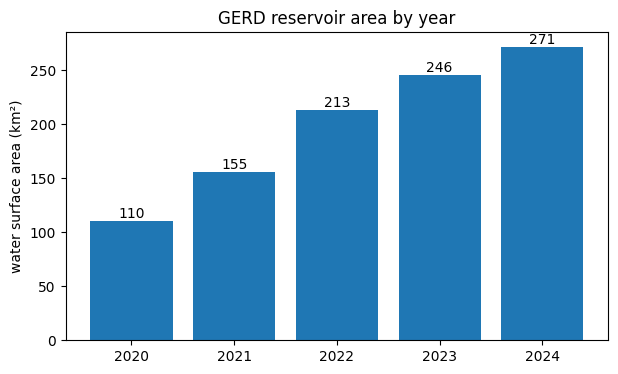

reservoir area (km²) by year: {'2020': 110, '2021': 155, '2022': 213, '2023': 246, '2024': 271}


In [3]:
# Water-surface area per year from the NDWI masks.
if ndwis:
    px_km2 = (30 * 30) / 1e6
    areas = [float(np.sum(n > 0.0) * px_km2) for n in ndwis]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, areas, color="tab:blue")
    ax.set(ylabel="water surface area (km²)", title="GERD reservoir area by year")
    for i, v in enumerate(areas): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
    plt.show()
    print("reservoir area (km²) by year:", {l: round(v) for l, v in zip(labels, areas)})
else:
    print("no scenes — set GEE credentials and rerun")

## Recap

The animation shows the reservoir filling qualitatively; NDWI turns it into a surface-area-per-year curve — the same approach used to monitor reservoirs, lakes, and wetlands from space.

## Try it yourself

- Point `AOI` at another reservoir, or add months for a smoother animation.
- Convert area to approximate volume with a depth model.
- See the [GEE backend reference](../../reference/gee/introduction.md).